# 01 - Simulation du Modèle de Heston (Données Synthétiques)

Ce notebook présente la simulation du modèle de volatilité stochastique de Heston en utilisant la méthode d'Euler-Maruyama.

## Objectifs

1. Implémenter la simulation du modèle Heston (Euler-Maruyama)
2. Générer des trajectoires de prix et de variance
3. Visualiser les données synthétiques (prix, variance, volatilité implicite)

## 1. Importation des Bibliothèques

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Import du simulateur Heston
sys.path.append('../src')
from simulation.heston_sim import HestonSimulator

## 2. Définition des Paramètres du Modèle Heston

Le modèle de Heston est défini par les paramètres suivants :

- **S0** : Prix initial de l'actif
- **v0** : Variance initiale
- **μ** : Taux de rendement espéré (drift)
- **κ** : Vitesse de retour à la moyenne
- **θ** : Variance de long terme
- **σ** : Volatilité de la variance (vol of vol)
- **ρ** : Corrélation entre les processus

In [2]:
# Paramètres du modèle Heston
heston_params = {
    'S0': 100.0,      # Prix initial
    'v0': 0.04,       # Variance initiale (volatilité initiale = 20%)
    'mu': 0.05,       # Taux de rendement espéré (5%)
    'kappa': 2.0,     # Vitesse de retour à la moyenne
    'theta': 0.04,    # Variance de long terme (volatilité long terme = 20%)
    'sigma': 0.3,     # Volatilité de la variance (30%)
    'rho': -0.7,      # Corrélation négative (effet leverage)
    'T': 1.0,         # Horizon temporel (1 an)
    'dt': 1/252,      # Pas de temps (1 jour de trading)
    'seed': 42        # Graine pour la reproductibilité
}

print("Paramètres du modèle Heston:")
for key, value in heston_params.items():
    print(f"  {key}: {value}")

Paramètres du modèle Heston:
  S0: 100.0
  v0: 0.04
  mu: 0.05
  kappa: 2.0
  theta: 0.04
  sigma: 0.3
  rho: -0.7
  T: 1.0
  dt: 0.003968253968253968
  seed: 42


## 3. Vérification de la Condition de Feller

La condition de Feller garantit que la variance reste strictement positive :

$$2\kappa\theta \geq \sigma^2$$

In [3]:
# Vérification de la condition de Feller
kappa = heston_params['kappa']
theta = heston_params['theta']
sigma = heston_params['sigma']

feller_lhs = 2 * kappa * theta
feller_rhs = sigma**2

print(f"Condition de Feller:")
print(f"  2κθ = {feller_lhs:.4f}")
print(f"  σ² = {feller_rhs:.4f}")
print(f"  Condition satisfaite: {feller_lhs >= feller_rhs}")

if feller_lhs >= feller_rhs:
    print("  ✓ La variance restera strictement positive.")
else:
    print("  ✗ La variance peut atteindre zéro (réflexion à zéro).")

Condition de Feller:
  2κθ = 0.1600
  σ² = 0.0900
  Condition satisfaite: True
  ✓ La variance restera strictement positive.


## 4. Création du Simulateur et Simulation

In [4]:
# Création du simulateur
simulator = HestonSimulator(**heston_params)

# Simulation de 10 trajectoires
n_paths = 10
S, v, t = simulator.simulate(n_paths=n_paths)

print(f"Simulation terminée!")
print(f"  Nombre de trajectoires: {n_paths}")
print(f"  Nombre de pas de temps: {len(t)}")
print(f"  Horizon temporel: {heston_params['T']} an(s)")
print(f"  Pas de temps: {heston_params['dt']:.6f} an(s) ({heston_params['dt']*252:.2f} jour(s))")

Simulation terminée!
  Nombre de trajectoires: 10
  Nombre de pas de temps: 253
  Horizon temporel: 1.0 an(s)
  Pas de temps: 0.003968 an(s) (1.00 jour(s))


## 5. Visualisation des Trajectoires

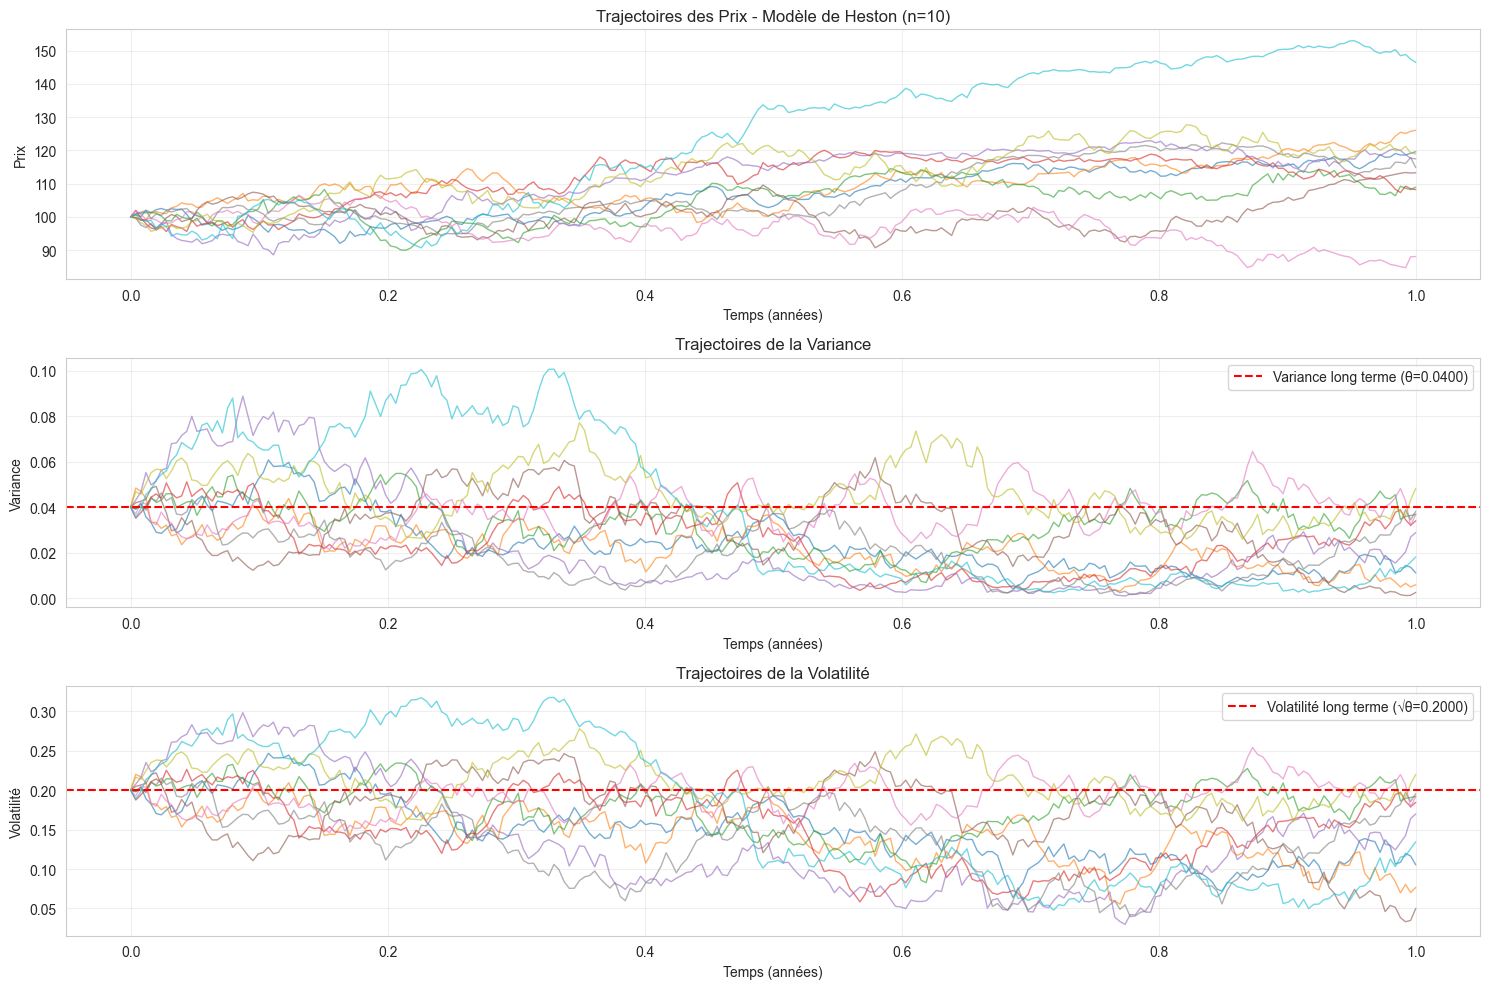

In [5]:
# Visualisation des trajectoires
simulator.plot_paths(n_paths_to_plot=n_paths)

## 6. Analyse Détaillée d'une Trajectoire

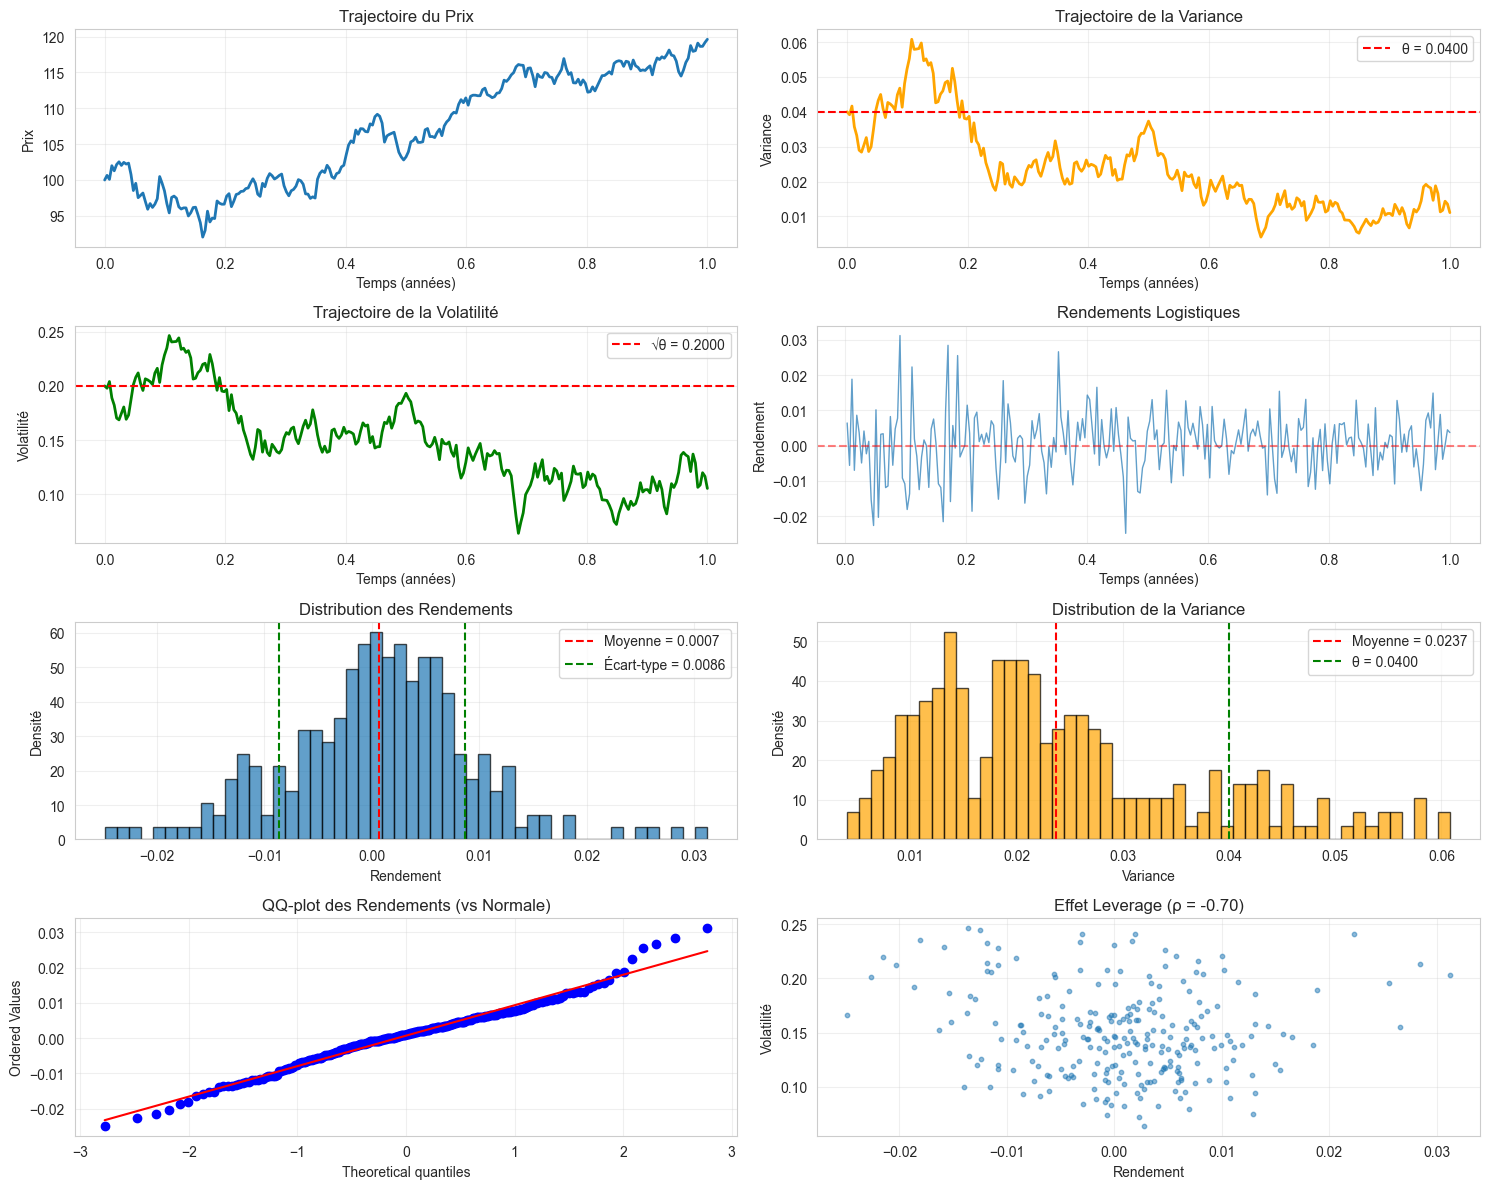

In [6]:
# Analyse détaillée de la première trajectoire
simulator.plot_single_path(path_idx=0)

## 7. Résumé Statistique

In [7]:
# Affichage du résumé statistique
simulator.print_summary()

RÉSUMÉ DE LA SIMULATION HESTON

Paramètres:
  S0: 100.0
  v0: 0.04
  mu: 0.05
  kappa: 2.0
  theta: 0.04
  sigma: 0.3
  rho: -0.7
  T: 1.0
  dt: 0.003968253968253968
  n_steps: 252
  n_paths: 10
  feller_condition: True

Statistiques des Prix:
  moyenne: 108.6815
  écart-type: 11.8673
  min: 84.7099
  max: 153.0049
  final: 116.1978

Statistiques de la Variance:
  moyenne: 0.0299
  écart-type: 0.0186
  min: 0.0009
  max: 0.1007
  final: 0.0261

Statistiques de la Volatilité:
  moyenne: 0.1636
  écart-type: 0.0558
  min: 0.0298
  max: 0.3174

Statistiques des Rendements:
  moyenne: 0.0006
  écart-type: 0.0107
  skewness: 0.2197
  kurtosis: 1.5049


## 8. Surface de Volatilité Implicite (Approximation)

Note: Ceci est une approximation basée sur la volatilité locale. Pour une vraie surface de volatilité implicite, il faut utiliser la formule de Heston pour le pricing d'options.

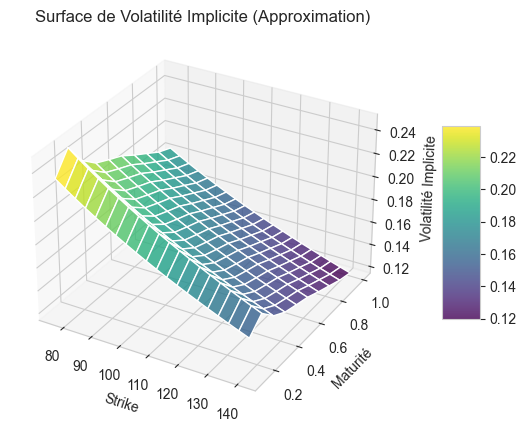

In [8]:
# Visualisation de la surface de volatilité implicite
simulator.plot_implied_volatility_surface()

## 9. Analyse de l'Effet Leverage

L'effet leverage est la corrélation négative typique entre les rendements et la volatilité sur les marchés d'actions.

Corrélation empirique rendements-volatilité: -0.0679
Corrélation théorique (ρ): -0.7000


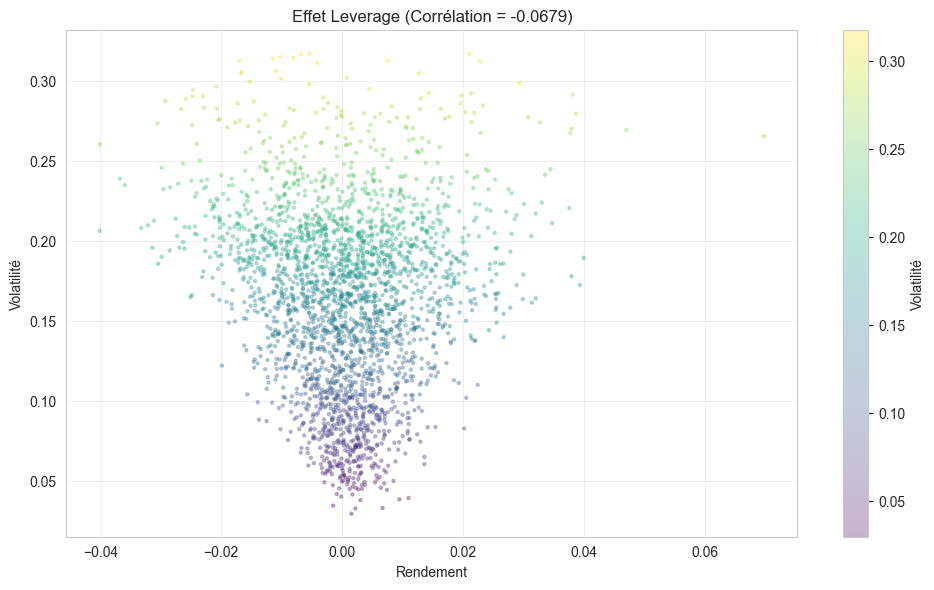

In [9]:
# Analyse de l'effet leverage
returns = simulator.get_returns()
volatility = simulator.get_volatility()

# Calcul de la corrélation empirique
correlation = np.corrcoef(returns.flatten(), volatility[1:, :].flatten())[0, 1]

print(f"Corrélation empirique rendements-volatilité: {correlation:.4f}")
print(f"Corrélation théorique (ρ): {heston_params['rho']:.4f}")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(returns.flatten(), volatility[1:, :].flatten(), 
                     alpha=0.3, s=5, c=volatility[1:, :].flatten(), 
                     cmap='viridis')
ax.set_xlabel('Rendement')
ax.set_ylabel('Volatilité')
ax.set_title(f'Effet Leverage (Corrélation = {correlation:.4f})')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Volatilité')
plt.tight_layout()
plt.show()

## 10. Analyse des Clusters de Volatilité

Les modèles de volatilité stochastique capturent les clusters de volatilité : périodes de haute volatilité suivies de périodes de calme.

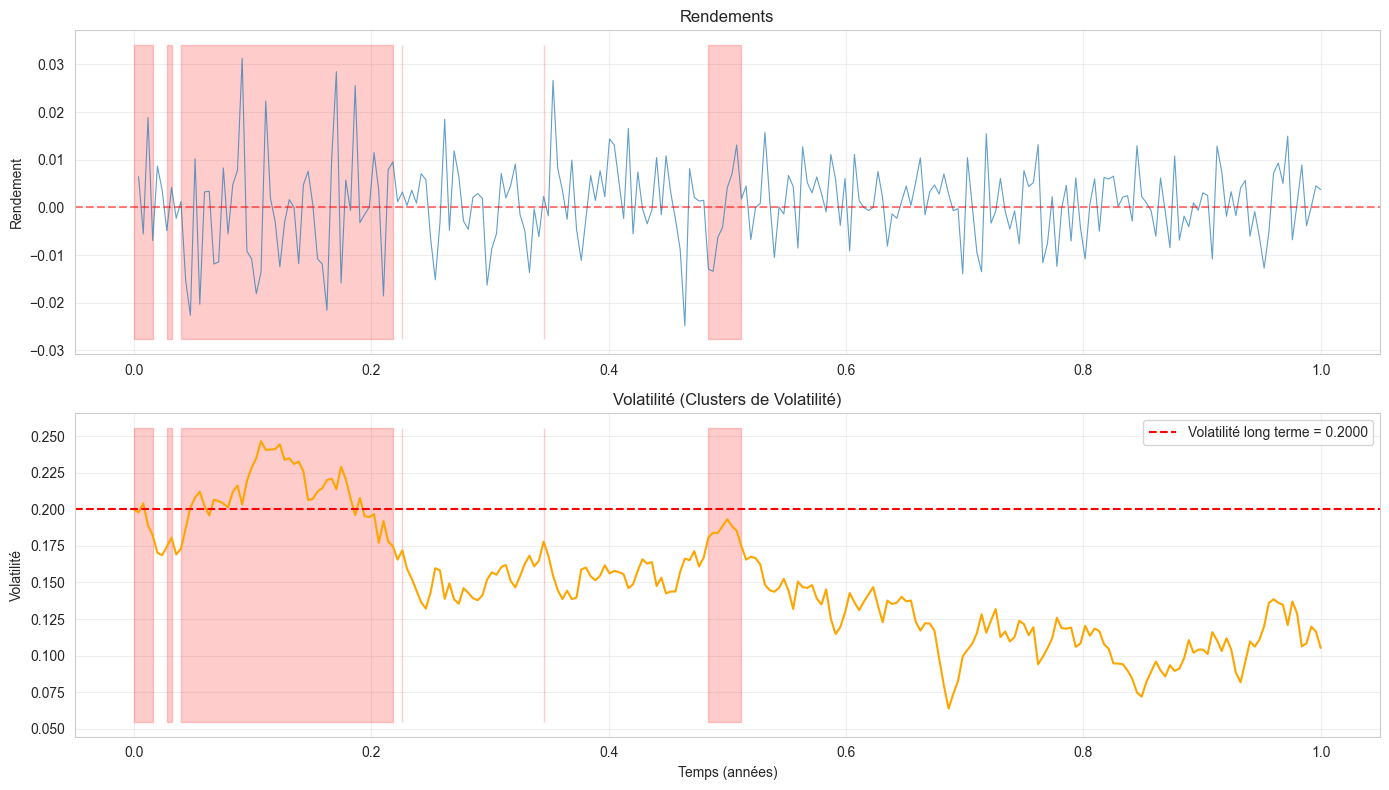

Seuil de haute volatilité (75ème percentile): 0.1714
Proportion de temps en haute volatilité: 24.90%


In [10]:
# Analyse des clusters de volatilité
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Rendements
axes[0].plot(t[1:], returns[:, 0], linewidth=0.8, alpha=0.7)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Rendement')
axes[0].set_title('Rendements')
axes[0].grid(True, alpha=0.3)

# Volatilité
axes[1].plot(t, volatility[:, 0], linewidth=1.5, color='orange')
axes[1].axhline(y=np.sqrt(theta), color='r', linestyle='--', 
               label=f'Volatilité long terme = {np.sqrt(theta):.4f}')
axes[1].set_xlabel('Temps (années)')
axes[1].set_ylabel('Volatilité')
axes[1].set_title('Volatilité (Clusters de Volatilité)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Surligner les périodes de haute volatilité
high_vol_threshold = np.percentile(volatility[:, 0], 75)
high_vol_periods = volatility[:, 0] > high_vol_threshold

for ax in axes:
    ax.fill_between(t, ax.get_ylim()[0], ax.get_ylim()[1], 
                    where=high_vol_periods, alpha=0.2, color='red',
                    label='Haute volatilité')

plt.tight_layout()
plt.show()

print(f"Seuil de haute volatilité (75ème percentile): {high_vol_threshold:.4f}")
print(f"Proportion de temps en haute volatilité: {np.mean(high_vol_periods)*100:.2f}%")

## 11. Comparaison avec Différents Paramètres

Comparons les trajectoires avec différentes valeurs de ρ (corrélation).

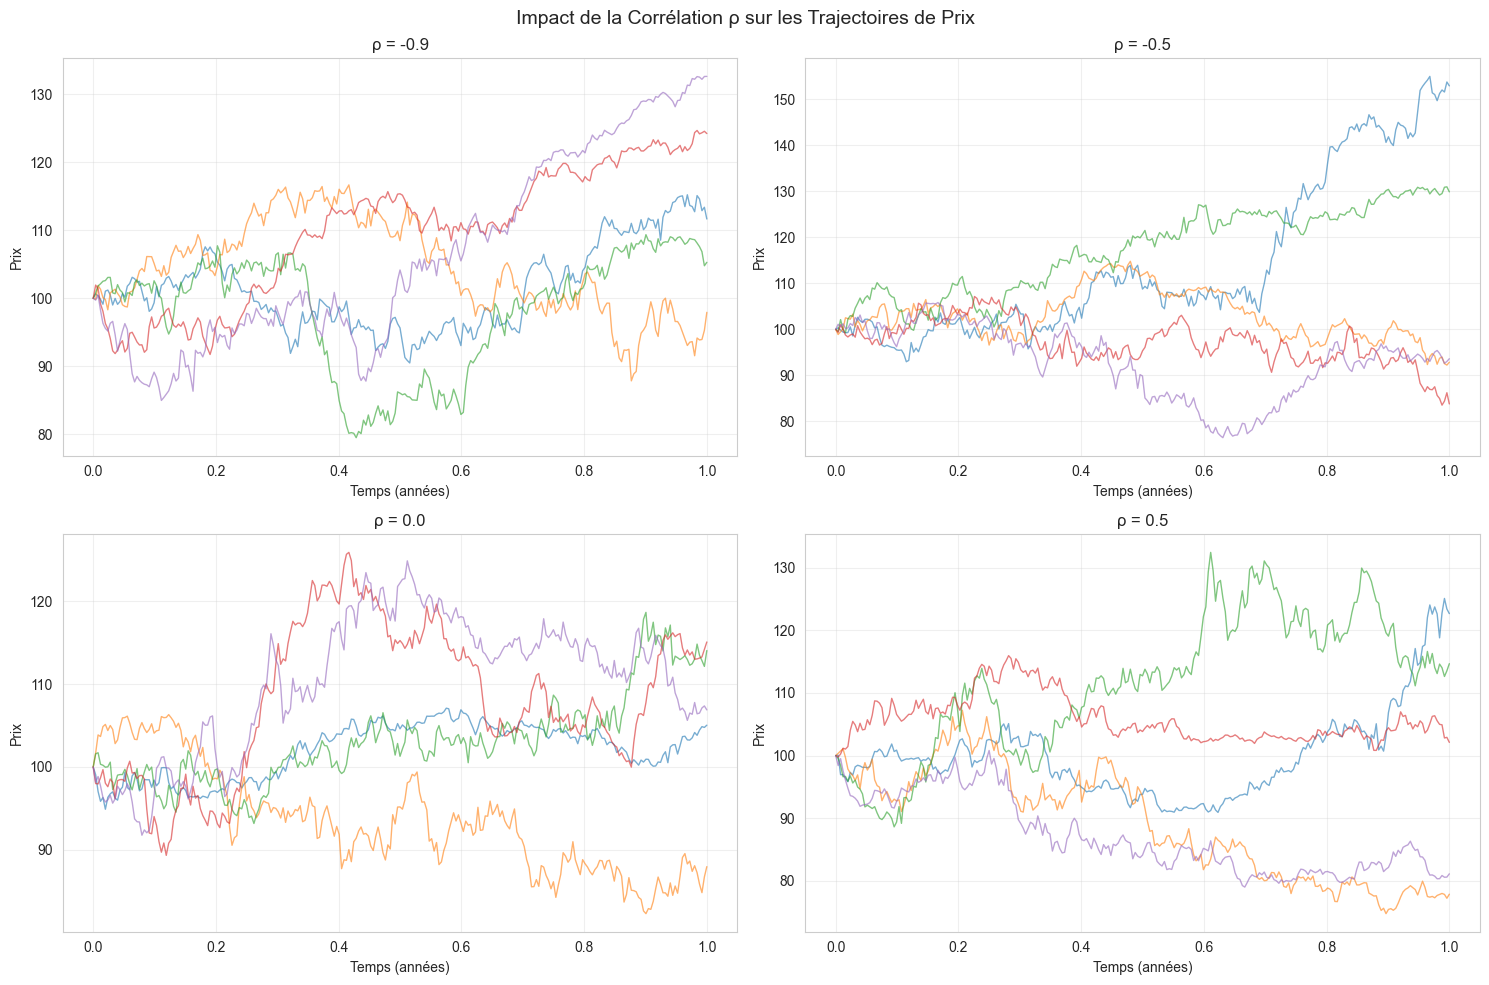

In [11]:
# Simulation avec différentes valeurs de ρ
rho_values = [-0.9, -0.5, 0.0, 0.5]
n_paths_comparison = 5

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, rho in enumerate(rho_values):
    params = heston_params.copy()
    params['rho'] = rho
    params['seed'] = 42 + idx  # Différentes graines
    
    sim = HestonSimulator(**params)
    S_rho, v_rho, t_rho = sim.simulate(n_paths=n_paths_comparison)
    
    # Tracer les trajectoires de prix
    for i in range(n_paths_comparison):
        axes[idx].plot(t_rho, S_rho[:, i], alpha=0.6, linewidth=1)
    
    axes[idx].set_xlabel('Temps (années)')
    axes[idx].set_ylabel('Prix')
    axes[idx].set_title(f'ρ = {rho:.1f}')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Impact de la Corrélation ρ sur les Trajectoires de Prix', fontsize=14)
plt.tight_layout()
plt.show()

## 12. Conclusion

Dans ce notebook, nous avons :

1. ✓ Implémenté la simulation du modèle Heston avec la méthode d'Euler-Maruyama
2. ✓ Généré des trajectoires de prix et de variance
3. ✓ Visualisé les données synthétiques (prix, variance, volatilité)

### Points clés observés :

- La variance suit un processus de retour à la moyenne vers θ
- La volatilité montre des clusters (périodes de haute et basse volatilité)
- L'effet leverage (ρ < 0) crée une corrélation négative entre rendements et volatilité
- La condition de Feller garantit la positivité de la variance

### Prochaines étapes :

- Définir le modèle probabiliste dans NumPyro
- Implémenter l'inférence MCMC
- Estimer les paramètres sur les données synthétiques
- Comparer les paramètres estimés avec les vrais paramètres